In [118]:
from veripulse.pulse import PulseConfig, PulseResult
import re
import json
import numpy as np
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

In [119]:
# data folder
data_dir = Path.cwd().parent/"data"

# file naming pattern
_PATTERN = re.compile(
    r"^(?P<method>[^_]+)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-(?P<identification>.+)\.json$"
)

# GRAPE_AVG:  GRAPE_AVG_pN_detX.XX_errX.XX-lamX.X-ID.json
_PATTERN_AVG = re.compile(
    r"^(?P<method>GRAPE_AVG)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-lam(?P<lam>[\d.]+)-(?P<identification>.+)\.json$"
)

# parsers

def parse_filename(path: Path) -> Optional[dict]:
    # Try GRAPE_AVG first (more specific), then fall back to generic
    m = _PATTERN_AVG.match(path.name) or _PATTERN.match(path.name)
    if not m:
        return None
    d = {
        "path":           path,
        "method":         m.group("method"),
        "num_tslots":     int(m.group("num_tslots")),
        "detuning":       float(m.group("detuning")),
        "drive_error":    float(m.group("drive_error")),
        "identification": m.group("identification"),
        "lam":            float(m.group("lam")) if "lam" in m.groupdict() and m.group("lam") is not None else None,
    }
    return d

def collect_files(
    directory: str | Path,
    method: Optional[str] = None,
    num_tslots: Optional[int] = None,
    detuning: Optional[float] = None,
    drive_error: Optional[float] = None,
    identification: Optional[str] = None,
    lam: Optional[float] = None,
    load: bool = False,
) -> list[dict]:
    results = []
    for path in sorted(Path(directory).glob("*.json")):
        meta = parse_filename(path)
        if meta is None:
            continue

        if method        is not None and meta["method"]      != method:                               continue
        if num_tslots    is not None and meta["num_tslots"]  != num_tslots:                           continue
        if detuning      is not None and f"{meta['detuning']:.2f}"    != f"{detuning:.2f}":           continue
        if drive_error   is not None and f"{meta['drive_error']:.2f}" != f"{drive_error:.2f}":        continue
        if identification is not None and meta["identification"] != str(identification):               continue
        if lam           is not None and (meta["lam"] is None or f"{meta['lam']:.1f}" != f"{lam:.1f}"): continue

        if load:
            with open(path) as f:
                meta["data"] = json.load(f)

        results.append(meta)

    return results


def plot_summary_property(
    summaries: dict,
    quantity: str,
    log_y: bool = False,
):
    fig, ax = plt.subplots(figsize=(6, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))

        means, stds = [], []
        for x in xs:
            vals = np.array(summary[x][quantity], dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())

        means = np.array(means)
        stds  = np.array(stds)

        line, = ax.plot(xs, means, lw=2.5, label=label)
        c = line.get_color()
        ax.fill_between(xs, means - stds, means + stds, alpha=0.18, color=c)

    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("x key")
    ax.set_ylabel(quantity)
    ax.set_title(quantity)
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.2, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_summary_properties(
    summaries: dict,
    quantities: list,
    log_y: bool = False,
    smearing: list = None,
):
    if smearing is None:
        smearing = [True] * len(quantities)

    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}

    fig, ax = plt.subplots(figsize=(7, 3))

    for quantity, ls, smear in zip(quantities, STYLES, smearing):
        for label, summary in summaries.items():
            xs = np.array(sorted(summary.keys()))
            means, stds = [], []
            for x in xs:
                vals = np.array(summary[x][quantity], dtype=float)
                means.append(vals.mean())
                stds.append(vals.std())
            means = np.array(means)
            stds  = np.array(stds)

            c = method_colors[label]
            ax.plot(xs, means, lw=2, ls=ls, color=c, label=f"{label} — {quantity}")
            if smear:
                ax.fill_between(xs, means - stds, means + stds, alpha=0.12, color=c)
    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=.3)
    ax.grid(True, linewidth=0.3, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()



def plot_summary_properties_extremes(
    summaries: dict,
    quantities: list,
    log_y: bool = False,
    cases: list = None,
):
    """
    Like plot_summary_properties but plots max or min instead of mean±std.

    Parameters
    ----------
    cases : list of {"max", "min"}
        One entry per quantity.  Defaults to all "max".
    """
    if cases is None:
        cases = ["max"] * len(quantities)

    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}

    fig, ax = plt.subplots(figsize=(7, 3))

    for quantity, ls, case in zip(quantities, STYLES, cases):
        agg = np.max if case == "max" else np.min
        for label, summary in summaries.items():
            xs = np.array(sorted(summary.keys()))
            ys = np.array([
                agg(np.array(summary[x][quantity], dtype=float))
                for x in xs
            ])
            c = method_colors[label]
            ax.plot(xs, ys, lw=2, ls=ls, color=c, marker ='o',
                    label=f"{label} — {quantity} ({case})")

    if log_y:
        ax.set_yscale('log')
    ax.set_xlabel("number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left',
              borderaxespad=.2)
    ax.grid(True, linewidth=0.2, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()

    
def summary_byslot(method, slots):
    summary = dict()
    for slot in slots: 
        summary[slot] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[]}
        runs = collect_files(data_dir, method=method, num_tslots=slot)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[slot]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[slot]['cost'].append(np.mean(res.err_hs_list)) 
            summary[slot]['si_lb'].append(res.si_lb)
            summary[slot]['si'].append(res.si)
            summary[slot]['diff'].append(res.si_lb - res.si)
            if method != 'GRAPE_AVG':
                # sum for all states 
                summary[slot]['eval'].append(sum(res.fid_compute_list))
            else : 
                summary[slot]['eval'].append(res.fid_compute_list)
    return summary

In [120]:
slots = [30, 40, 70, 100, 120]
summaries = dict()
summaries['GRAPE'] = summary_byslot("GRAPE", slots)
summaries['CRAB'] = summary_byslot('CRAB', slots)
summaries['GRAPE_AVG'] = summary_byslot('GRAPE_AVG', slots)

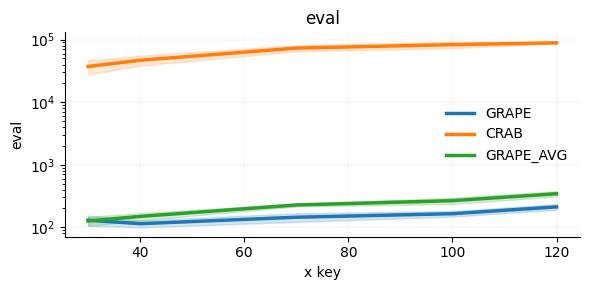

In [121]:
plot_summary_property(summaries = summaries, quantity='eval', log_y=True)

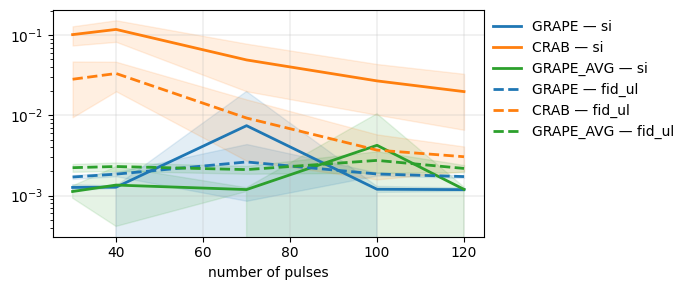

In [122]:
plot_summary_properties(
    summaries=summaries,
    quantities=['si','fid_ul'],
    log_y=True,
    smearing = [True, True]
)

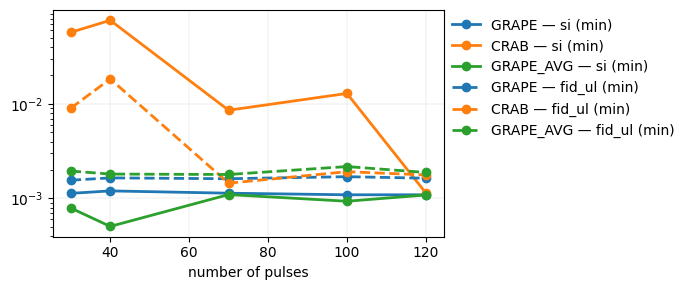

In [123]:
plot_summary_properties_extremes(
    summaries=summaries,
    quantities=['si', 'fid_ul'],
    log_y=True,
    cases=["min", "min"]
)